# Module 7 — Styling and Themes

This module is the matplotlib counterpart to ggplot2's `theme()` system and `theme_*()` functions.

The goal is to stop styling each plot individually and instead set defaults once. By the end, the direction is toward a reusable Radiology AI Unit style that automatically applies to every figure.

The core mental model:

```text
┌─────────────────────────────────────────────────────────┐
│ rcParams = a giant dictionary of default settings.      │
│ Every matplotlib function reads from it.                │
│                                                         │
│ Change rcParams once → every subsequent plot reflects   │
│ the change. No more repeating yourself.                 │
└─────────────────────────────────────────────────────────┘
```

There are three layers of styling, in increasing order of permanence:

```text
┌────────────────────────────────────────────────────────────┐
│ Layer 1: Per-plot keyword arguments                        │
│ ax.plot(x, y, color="red", linewidth=2)                   │
│ → applies only to this call                                │
├────────────────────────────────────────────────────────────┤
│ Layer 2: rcParams modification, session-wide               │
│ plt.rcParams["axes.titlesize"] = 14                       │
│ → applies to all plots in this Python session              │
├────────────────────────────────────────────────────────────┤
│ Layer 3: Style sheets / matplotlibrc files                 │
│ plt.style.use("my-style")                                 │
│ → reusable, version-controllable, shareable                │
└────────────────────────────────────────────────────────────┘
```

The previous modules mostly used Layer 1. This module moves upward.

## 1. `rcParams`: the central settings dictionary

`rcParams`, short for runtime configuration parameters, is a dictionary-like object with hundreds of settings.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Inspect a setting
print(plt.rcParams["figure.figsize"])
print(plt.rcParams["axes.titlesize"])

[7.0, 5.0]
large


The keys are dot-namespaced by what they affect, such as:

- `figure.*`
- `axes.*`
- `xtick.*`
- `ytick.*`
- `legend.*`
- `font.*`
- `lines.*`

Changing a setting affects future plots in the current Python session.

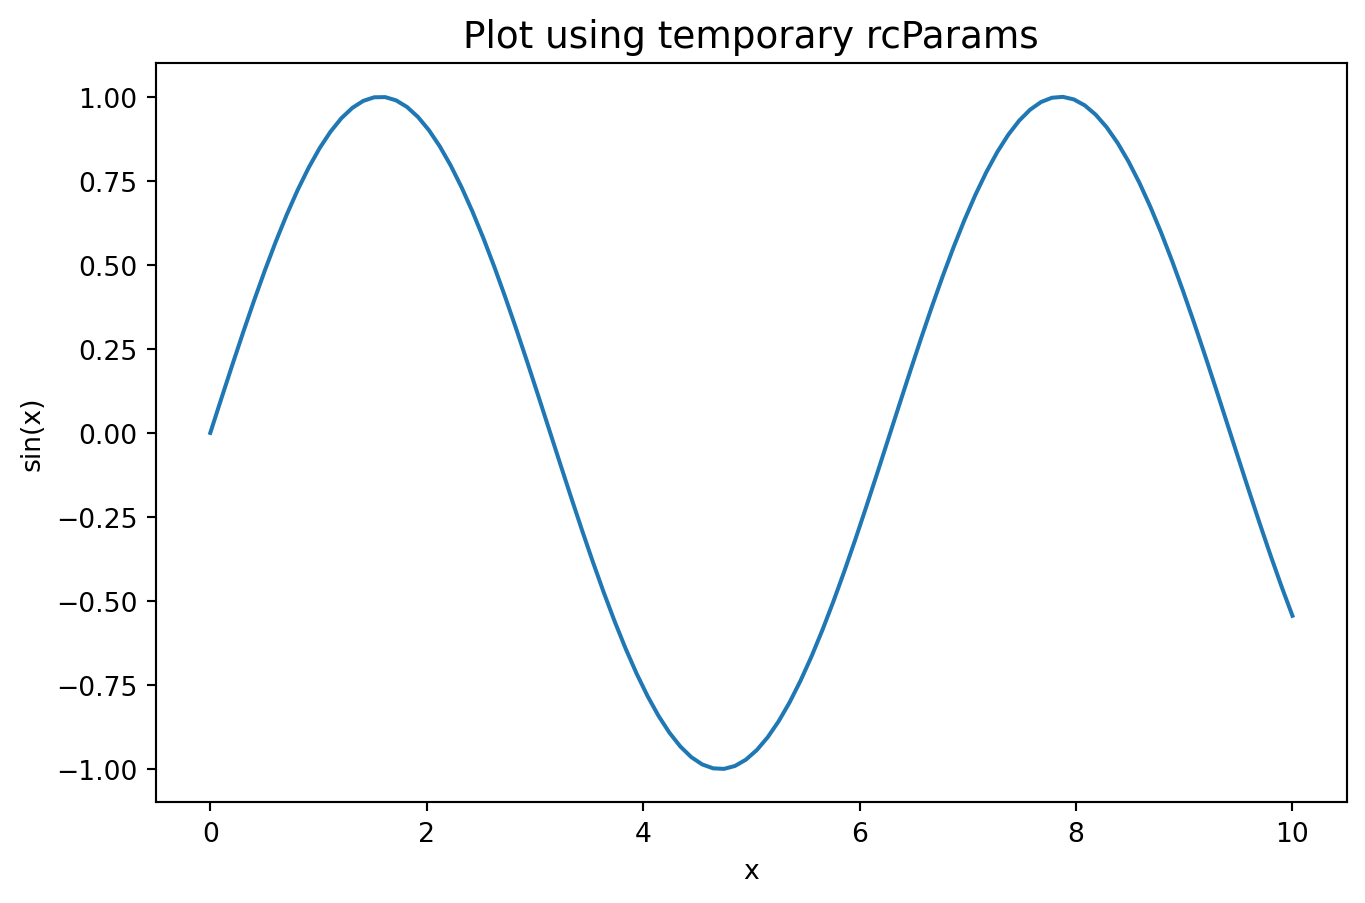

In [2]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

with mpl.rc_context({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.family": "sans-serif",
}):
    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_title("Plot using temporary rcParams")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    plt.show()

This example uses `mpl.rc_context(...)` so the settings are temporary and do not leak into the rest of the notebook. In normal project code, `plt.rcParams[...] = ...` or `plt.rcParams.update(...)` changes settings for all subsequent plots in the session.

A useful starter set:

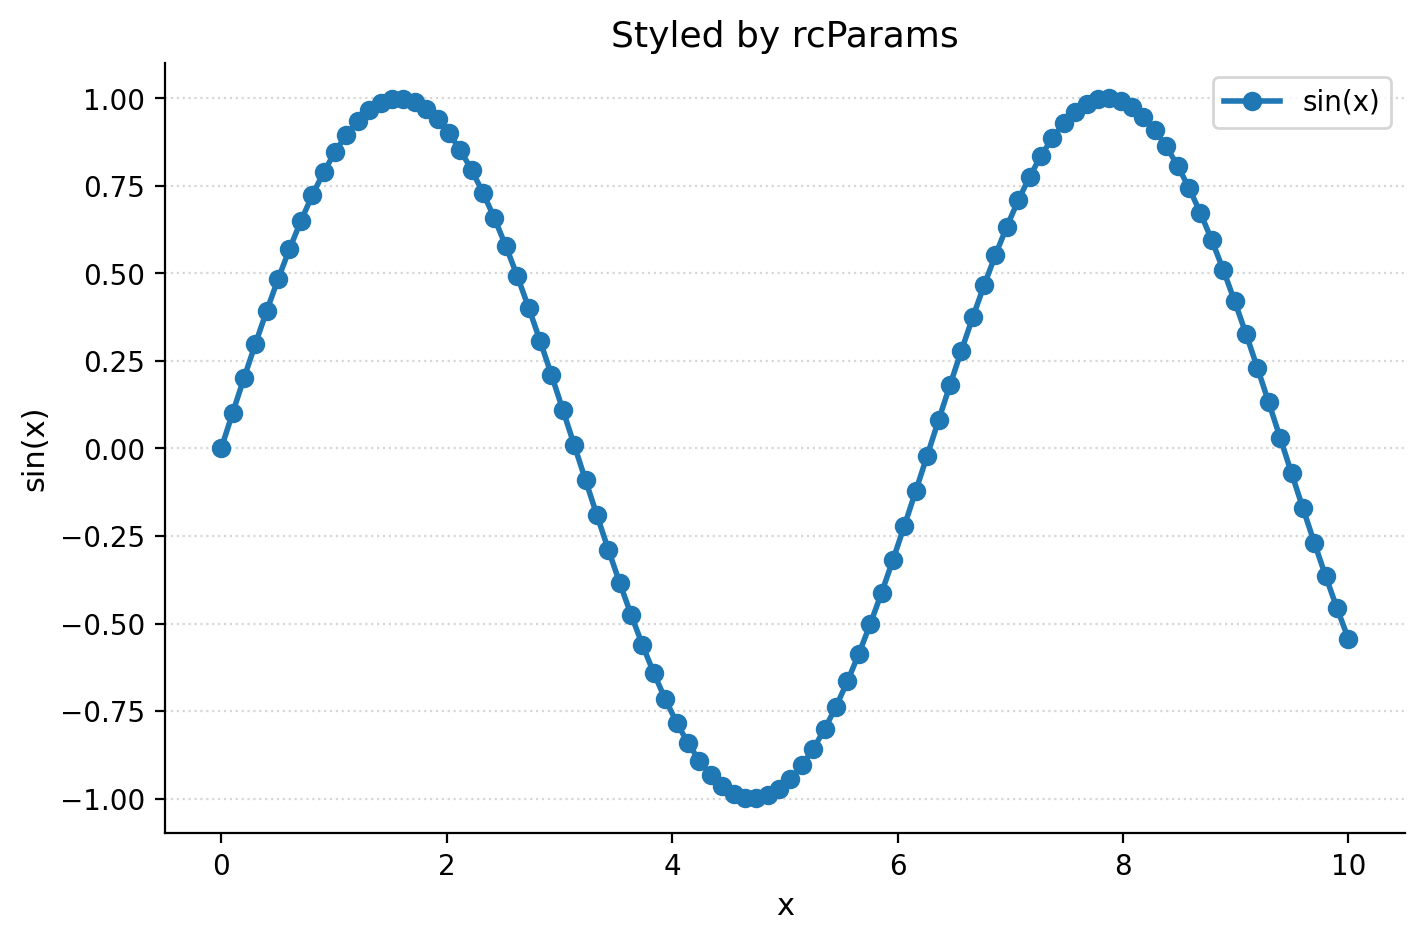

In [3]:
radiology_style = {
    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Axes appearance
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.linestyle": ":",
    "grid.alpha": 0.5,

    # Lines and markers
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
}

with mpl.rc_context(radiology_style):
    fig, ax = plt.subplots()
    ax.plot(x, y, marker="o", label="sin(x)")
    ax.set_title("Styled by rcParams")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    ax.legend()
    plt.show()

After these defaults are active, every new `fig, ax = plt.subplots()` inherits them. This removes repetitive boilerplate such as hiding the top and right spines or setting a light y-axis grid on every plot.

## 2. Discovering settings

There are two reliable discovery tools: search the keys and inspect the active `matplotlibrc` file.

In [4]:
# All rcParams keys that mention "tick"
tick_keys = [k for k in plt.rcParams if "tick" in k]
print(tick_keys[:20])
print(f"... {len(tick_keys)} tick-related keys total")

# Path to the active matplotlibrc reference file
print(mpl.matplotlib_fname())

['xtick.alignment', 'xtick.bottom', 'xtick.color', 'xtick.direction', 'xtick.labelbottom', 'xtick.labelcolor', 'xtick.labelsize', 'xtick.labeltop', 'xtick.major.bottom', 'xtick.major.pad', 'xtick.major.size', 'xtick.major.top', 'xtick.major.width', 'xtick.minor.bottom', 'xtick.minor.ndivs', 'xtick.minor.pad', 'xtick.minor.size', 'xtick.minor.top', 'xtick.minor.visible', 'xtick.minor.width']
... 42 tick-related keys total
/Users/kittipos/my_book/py-plot-notes/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc


To reset everything to factory defaults:

```python
plt.rcdefaults()
```

The full list of defaults lives in a file called `matplotlibrc` inside the matplotlib installation. Treat it as a reference, not something to edit directly.

Useful `rcParams` categories:

```text
figure.*        size, dpi, layout
axes.*          spines, titles, grid, prop_cycle (color cycle)
font.*          family, size, weight
xtick.*         label sizes, directions, lengths
ytick.*         label sizes, directions, lengths
legend.*        fontsize, frameon, loc
lines.*         linewidth, markersize, default style
savefig.*       dpi, bbox, format
```

## 3. The color cycle revisited

From Module 5, the default color cycle is set through `axes.prop_cycle`. To install a colorblind-safe palette globally, use `cycler`. In a notebook, it is safer to demonstrate this with a temporary context.

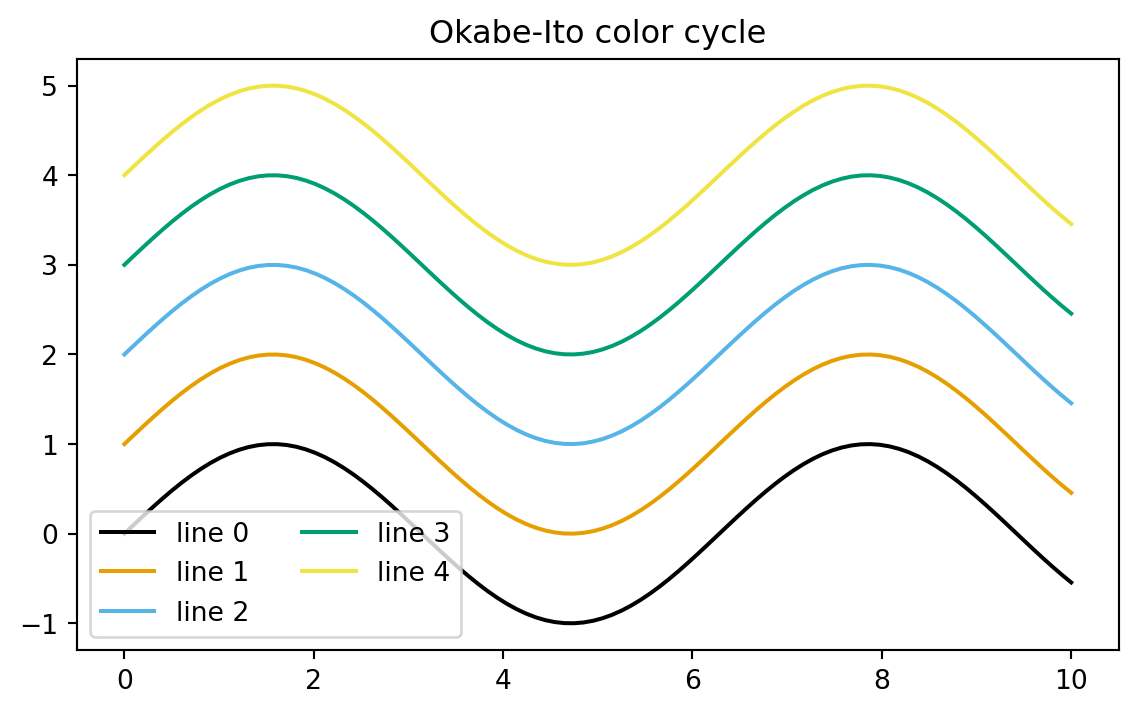

In [5]:
from cycler import cycler

okabe_ito = [
    "#000000", "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00", "#CC79A7",
]

with mpl.rc_context({"axes.prop_cycle": cycler(color=okabe_ito)}):
    fig, ax = plt.subplots(figsize=(7, 4))
    for i in range(5):
        ax.plot(x, np.sin(x) + i, label=f"line {i}")
    ax.legend(ncol=2)
    ax.set_title("Okabe-Ito color cycle")
    plt.show()

In a normal script or session, the persistent version would be:

```python
plt.rcParams["axes.prop_cycle"] = cycler(color=okabe_ito)
```

Multiple properties can cycle together, such as color and linestyle. This is useful for grayscale-printable figures.

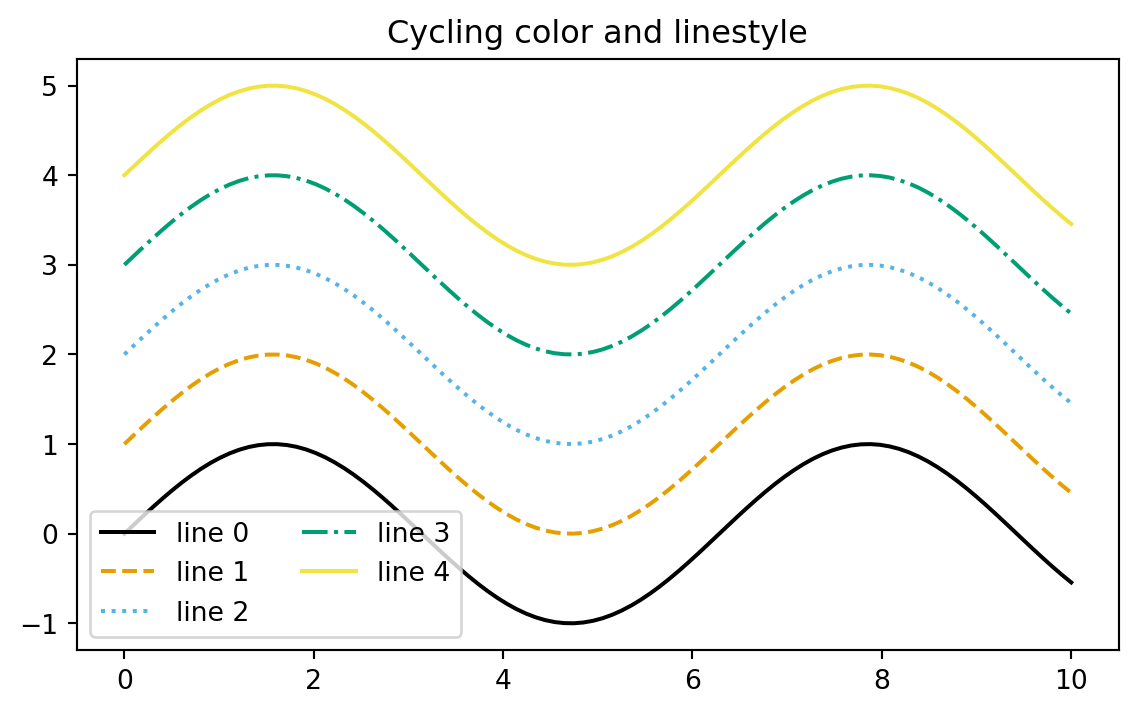

In [6]:
line_styles = ["-", "--", ":", "-.", "-", "--", ":", "-."]

with mpl.rc_context({"axes.prop_cycle": cycler(color=okabe_ito) + cycler(linestyle=line_styles)}):
    fig, ax = plt.subplots(figsize=(7, 4))
    for i in range(5):
        ax.plot(x, np.sin(x) + i, label=f"line {i}")
    ax.legend(ncol=2)
    ax.set_title("Cycling color and linestyle")
    plt.show()

## 4. Style sheets: reusable presets

A style sheet is a saved bundle of `rcParams` that can be activated in one line. Matplotlib ships with many styles.

In [7]:
print(plt.style.available[:12])
print(f"... {len(plt.style.available)} styles available")

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10']
... 29 styles available


Common examples include:

```python
plt.style.use("ggplot")
plt.style.use("seaborn-v0_8-whitegrid")
plt.style.use("default")
```

Use `plt.style.context(...)` for temporary styling that reverts after the `with` block.

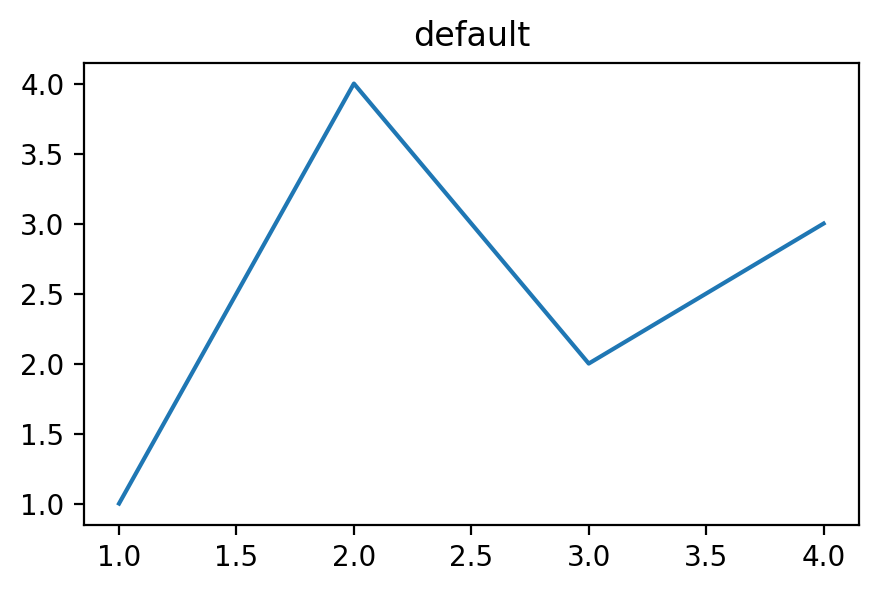

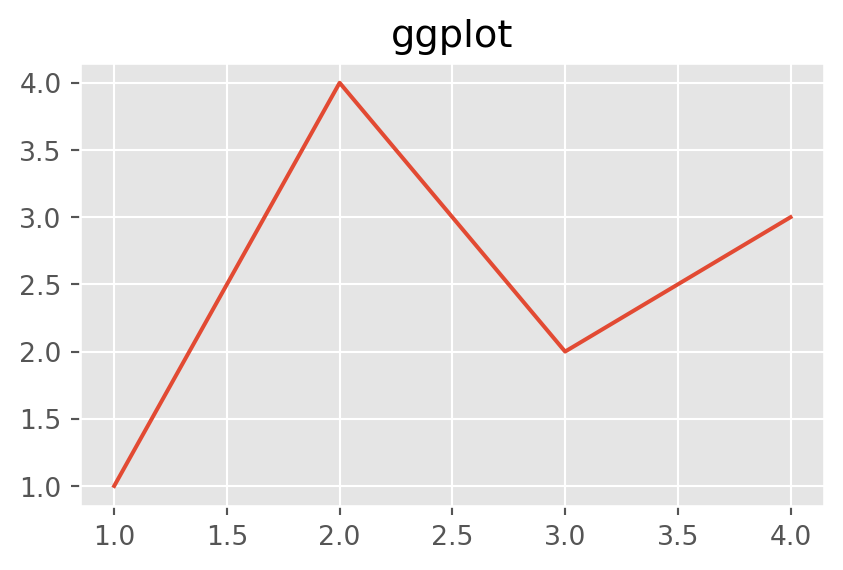

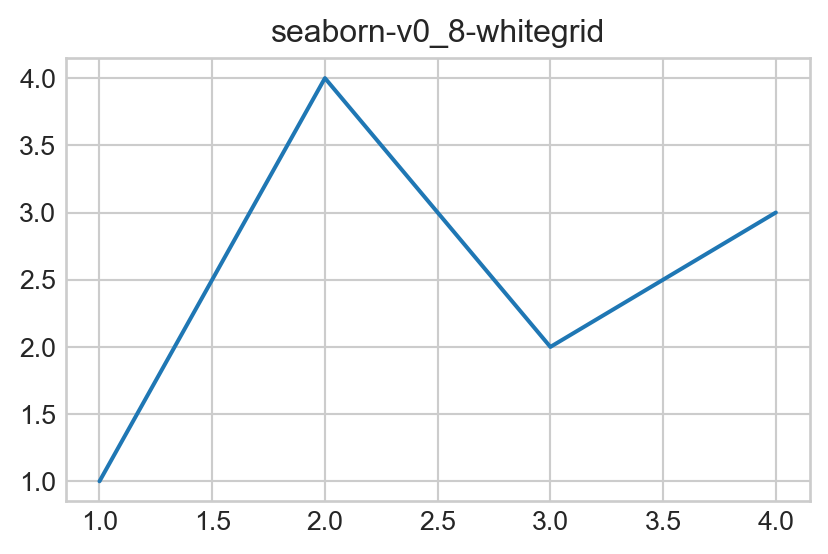

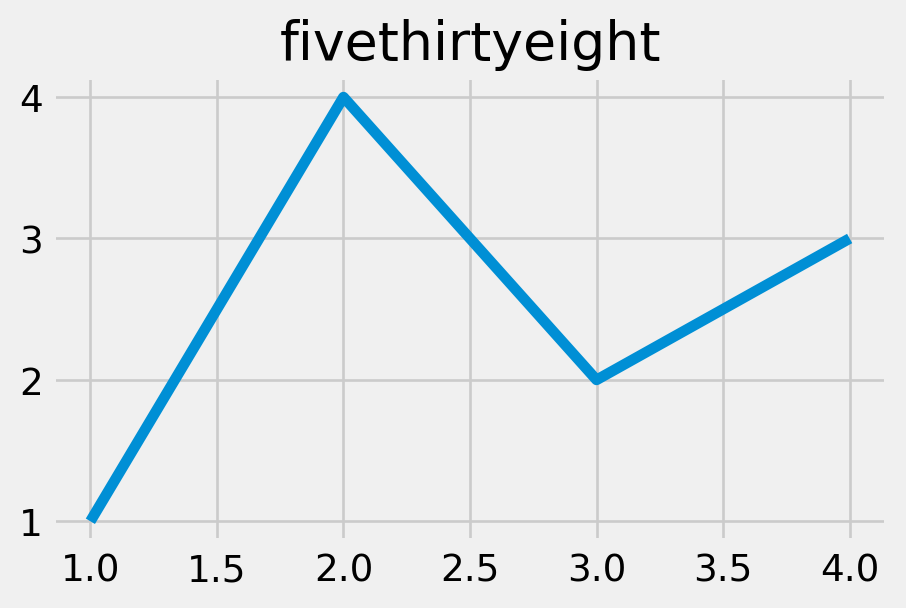

In [8]:
for style in ["default", "ggplot", "seaborn-v0_8-whitegrid", "fivethirtyeight"]:
    with plt.style.context(style):
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot([1, 2, 3, 4], [1, 4, 2, 3])
        ax.set_title(style)
        plt.show()

```text
plt.style.use(...)      permanent for the session
plt.style.context(...)  temporary, scoped to a with block
```

## 5. Writing a custom style sheet

A style sheet is a plain text file with one `key: value` setting per line. For a project, a version-controlled style file is usually better than a per-user style because it travels with the repository.

Example `styles/radai.mplstyle`:

```text
# Radiology AI Unit — publication style

figure.figsize: 8, 5
figure.dpi: 100
savefig.dpi: 300
savefig.bbox: tight

font.family: sans-serif
font.size: 11
axes.titlesize: 13
axes.titleweight: bold
axes.titlelocation: left
axes.labelsize: 11

axes.spines.top: False
axes.spines.right: False
axes.grid: True
axes.grid.axis: y
grid.linestyle: :
grid.alpha: 0.5
grid.color: gray

lines.linewidth: 2.0
lines.markersize: 6

xtick.direction: out
ytick.direction: out

legend.frameon: False
legend.fontsize: 10

axes.prop_cycle: cycler('color', ['000000', 'E69F00', '56B4E9', '009E73', 'F0E442', '0072B2', 'D55E00', 'CC79A7'])
```

Syntax notes:

- no quotes around strings
- comma separates `figsize` width and height
- colors inside `prop_cycle` omit `#`
- lines starting with `#` are comments

Where to put the style file:

```text
Per-user:
~/.matplotlib/stylelib/myname.mplstyle
→ use as: plt.style.use("myname")

Per-project:
/your/project/styles/myname.mplstyle
→ use as: plt.style.use("/your/project/styles/myname.mplstyle")
→ version-controlled and reproducible
```

For a Quarto book or paper repository, the per-project approach is usually preferable.

The current book can demonstrate this by writing a small project-local style file under `styles/`.

In [9]:
from pathlib import Path

style_dir = Path("styles")
style_dir.mkdir(exist_ok=True)
style_path = style_dir / "radai.mplstyle"
style_path.write_text("""# Radiology AI Unit — publication style

figure.figsize: 8, 5
figure.dpi: 100
savefig.dpi: 300
savefig.bbox: tight

font.family: sans-serif
font.size: 11
axes.titlesize: 13
axes.titleweight: bold
axes.titlelocation: left
axes.labelsize: 11

axes.spines.top: False
axes.spines.right: False
axes.grid: True
axes.grid.axis: y
grid.linestyle: :
grid.alpha: 0.5
grid.color: gray

lines.linewidth: 2.0
lines.markersize: 6

xtick.direction: out
ytick.direction: out

legend.frameon: False
legend.fontsize: 10

axes.prop_cycle: cycler('color', ['000000', 'E69F00', '56B4E9', '009E73', 'F0E442', '0072B2', 'D55E00', 'CC79A7'])
""")
print(style_path)

styles/radai.mplstyle


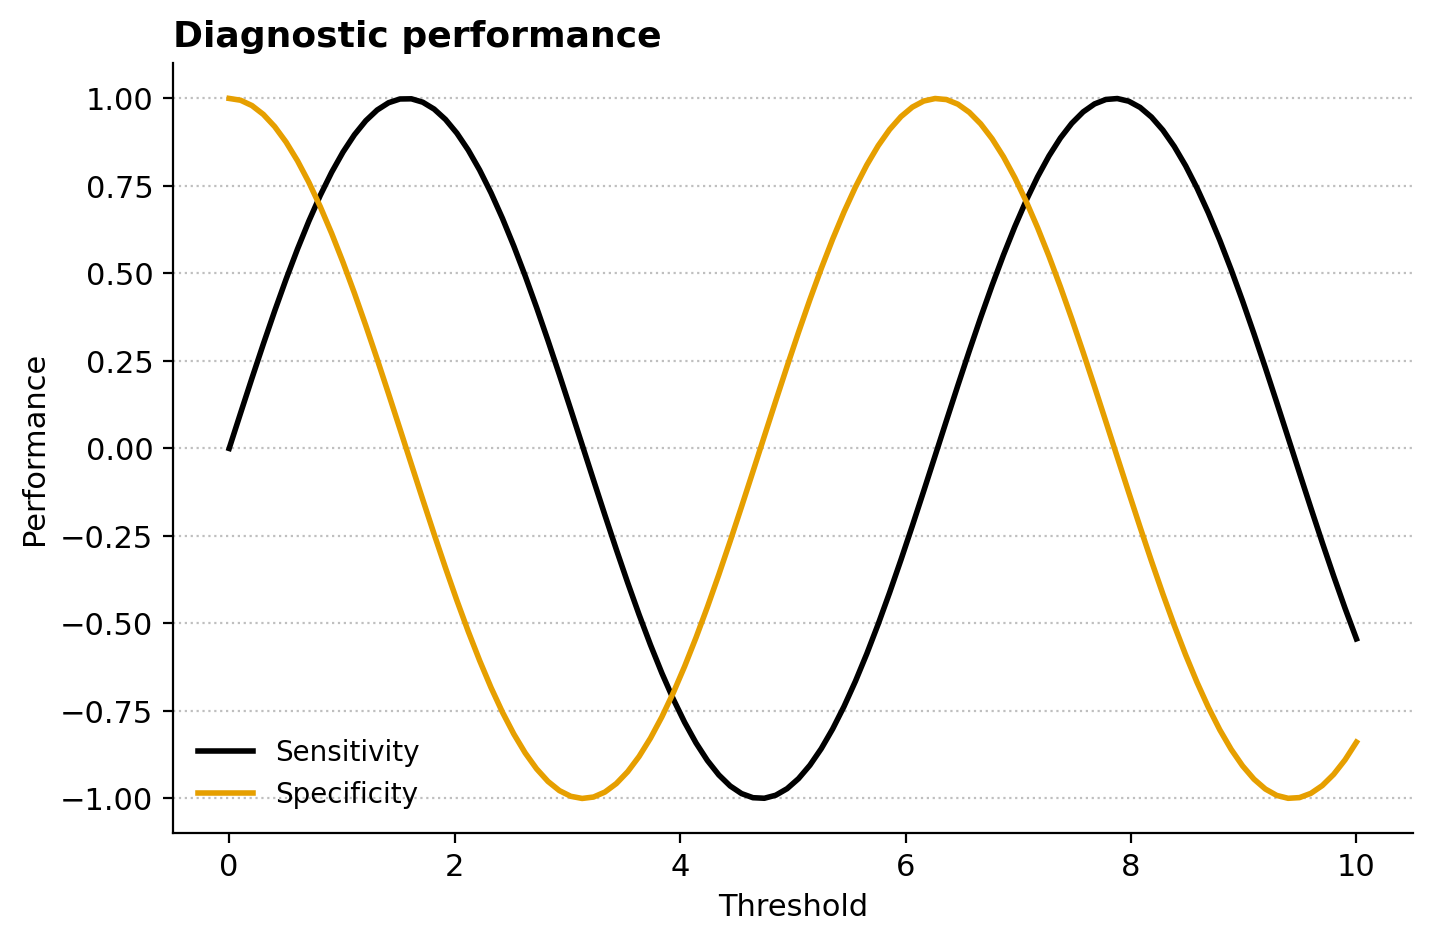

In [10]:
with plt.style.context("styles/radai.mplstyle"):
    fig, ax = plt.subplots()
    ax.plot(x, np.sin(x), label="Sensitivity")
    ax.plot(x, np.cos(x), label="Specificity")
    ax.set_title("Diagnostic performance")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Performance")
    ax.legend()
    plt.show()

## 6. Combining styles

Style sheets can be stacked. Later styles override earlier ones:

```python
plt.style.use(["seaborn-v0_8-whitegrid", "radai"])
```

This applies seaborn's whitegrid first, then applies local overrides on top.

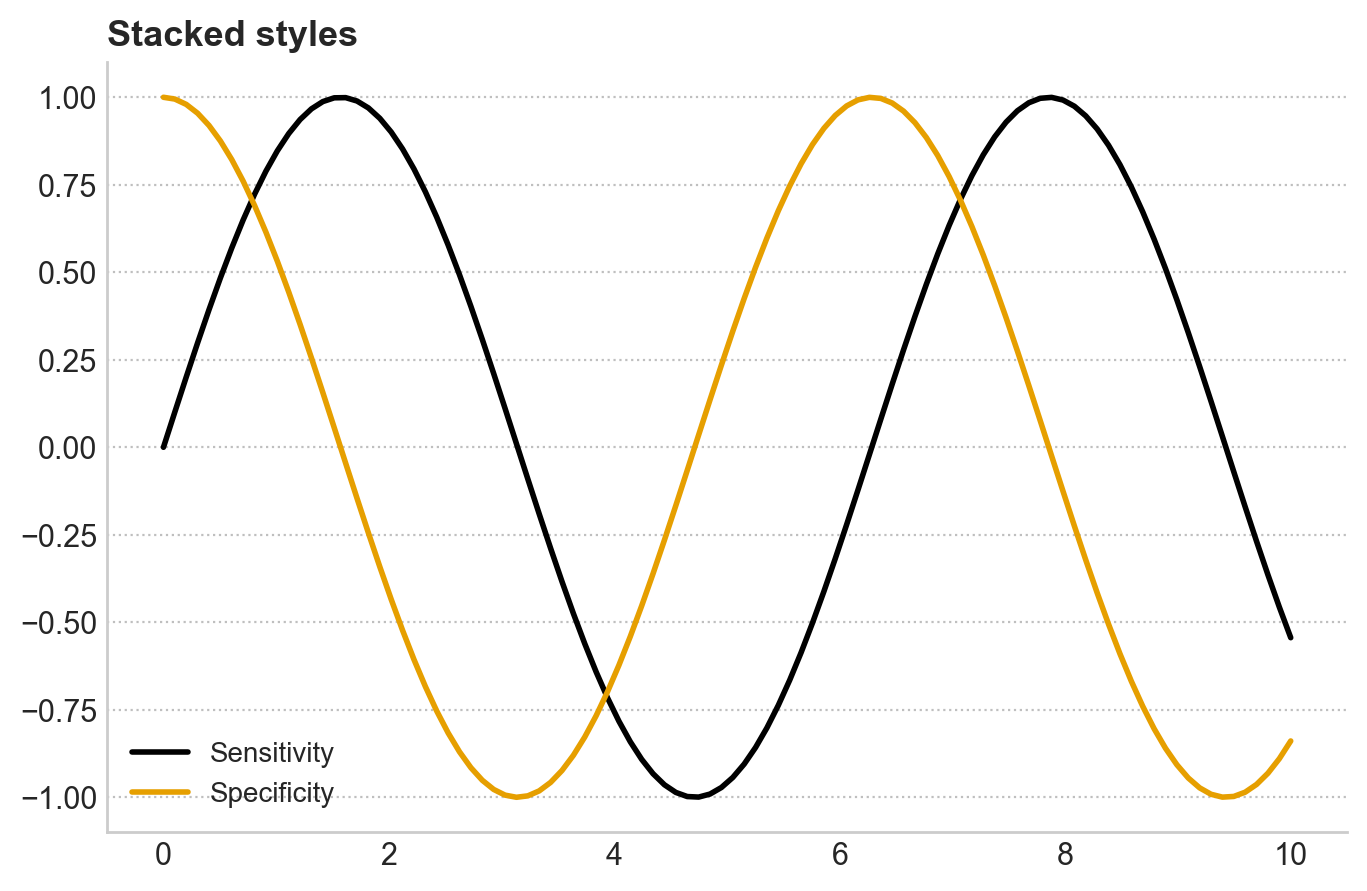

In [11]:
with plt.style.context(["seaborn-v0_8-whitegrid", "styles/radai.mplstyle"]):
    fig, ax = plt.subplots()
    ax.plot(x, np.sin(x), label="Sensitivity")
    ax.plot(x, np.cos(x), label="Specificity")
    ax.set_title("Stacked styles")
    ax.legend()
    plt.show()

## 7. The `with` pattern for one-off styling

Sometimes one figure should look different, such as a slide figure needing larger fonts. Use a context manager.

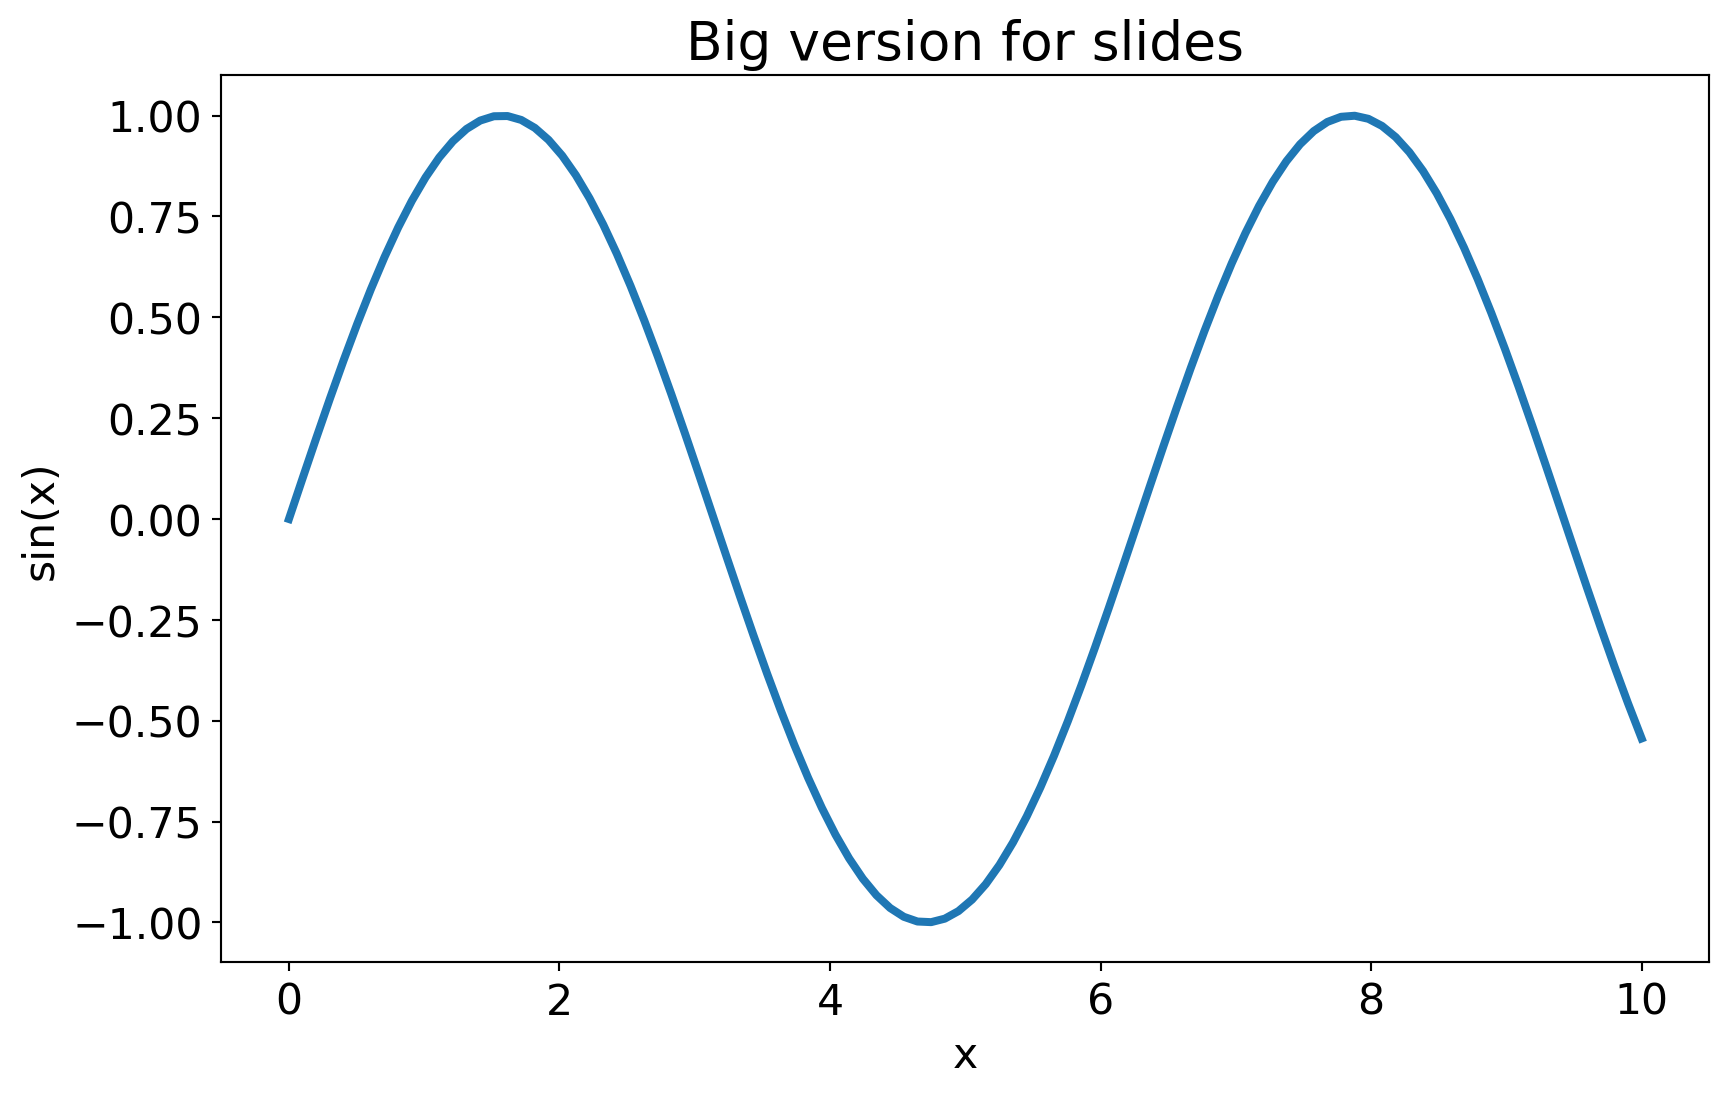

In [12]:
with plt.rc_context({"font.size": 16, "axes.titlesize": 20, "lines.linewidth": 3}):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, np.sin(x))
    ax.set_title("Big version for slides")
    ax.set_xlabel("x")
    ax.set_ylabel("sin(x)")
    plt.show()

# After the with block, settings return to normal.

`plt.rc_context()` is the `rcParams` equivalent of `plt.style.context()`. Use a dictionary for ad-hoc tweaks and a style sheet for systematic styling.

## 8. ggplot2 → matplotlib styling cheat sheet

| ggplot2 | matplotlib |
|---|---|
| `theme_minimal()` | `plt.style.use("seaborn-v0_8-whitegrid")` |
| `theme_bw()` | `plt.style.use("seaborn-v0_8-white")` |
| `theme_set(theme_minimal())` | `plt.style.use("...")` for the session |
| `theme(text = element_text(size = 12))` | `plt.rcParams["font.size"] = 12` |
| `theme(axis.text.x = element_text(angle = 45))` | `plt.rcParams["xtick.labelrotation"] = 45` |
| `theme(legend.position = "none")` | no exact global equivalent; often control per-axes |
| custom theme function in R | custom `.mplstyle` file |

The biggest conceptual difference: ggplot2 themes are functions that can be composed. Matplotlib styles are flat key-value files. They are less expressive but very easy to share.

## 9. Practical workflow recommendation

For radiology AI work, Quarto technical docs, and publication figures, a practical workflow is:

```text
┌──────────────────────────────────────────────────────────┐
│ 1. One project-local style file: styles/radai.mplstyle   │
│    → captures fonts, palette, spine treatment, sizes     │
│                                                          │
│ 2. At the top of every notebook / script:                │
│    plt.style.use("styles/radai.mplstyle")                │
│                                                          │
│ 3. For a different output context, such as slides,       │
│    create radai-slides.mplstyle and use it instead.      │
│                                                          │
│ 4. For one-off tweaks, use plt.rc_context().             │
└──────────────────────────────────────────────────────────┘
```

Two style sheets can cover most cases:

- `radai-paper.mplstyle`: smaller figure and font sizes for journal columns
- `radai-slides.mplstyle`: larger figure and font sizes for projection

Same color palette, same spine treatment, different sizing.

## 10. Complete example: before and after

The same plotting function can produce different appearances depending only on the active style.

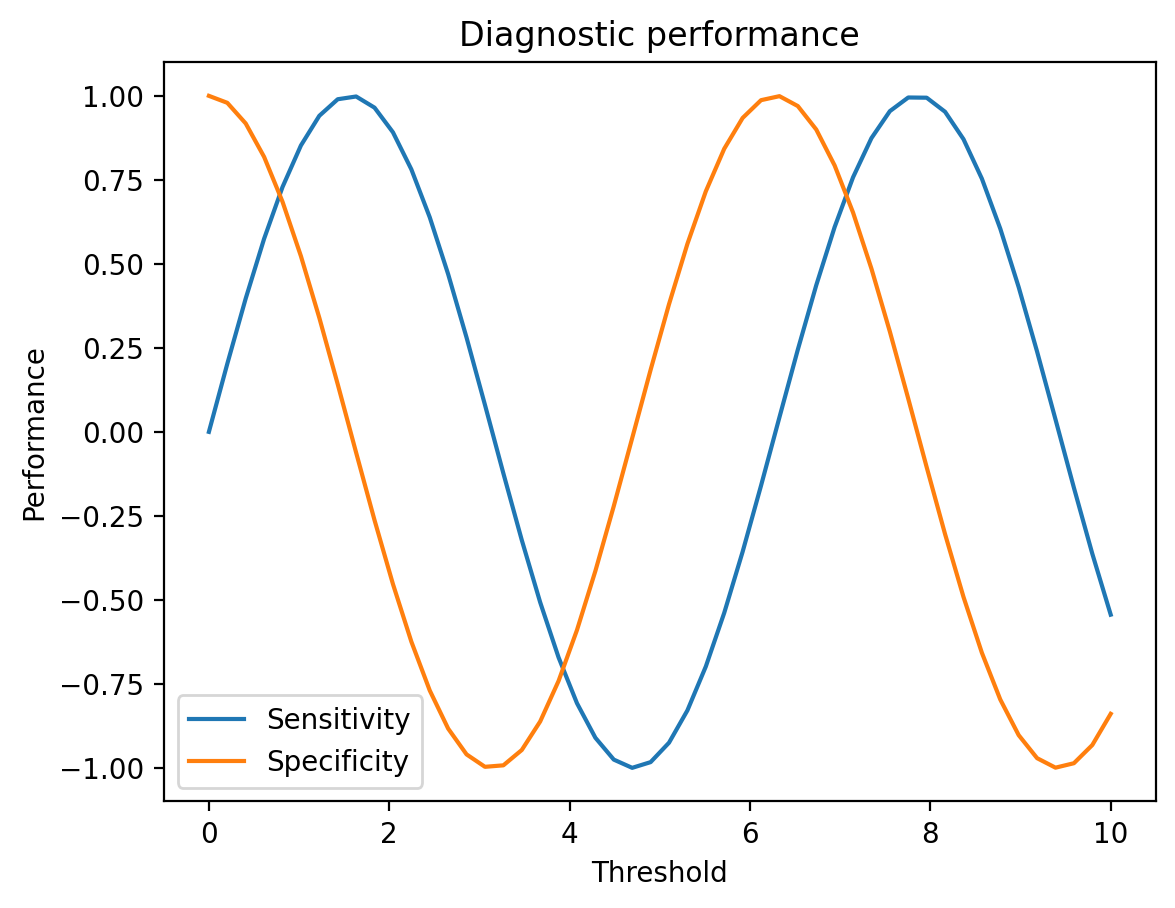

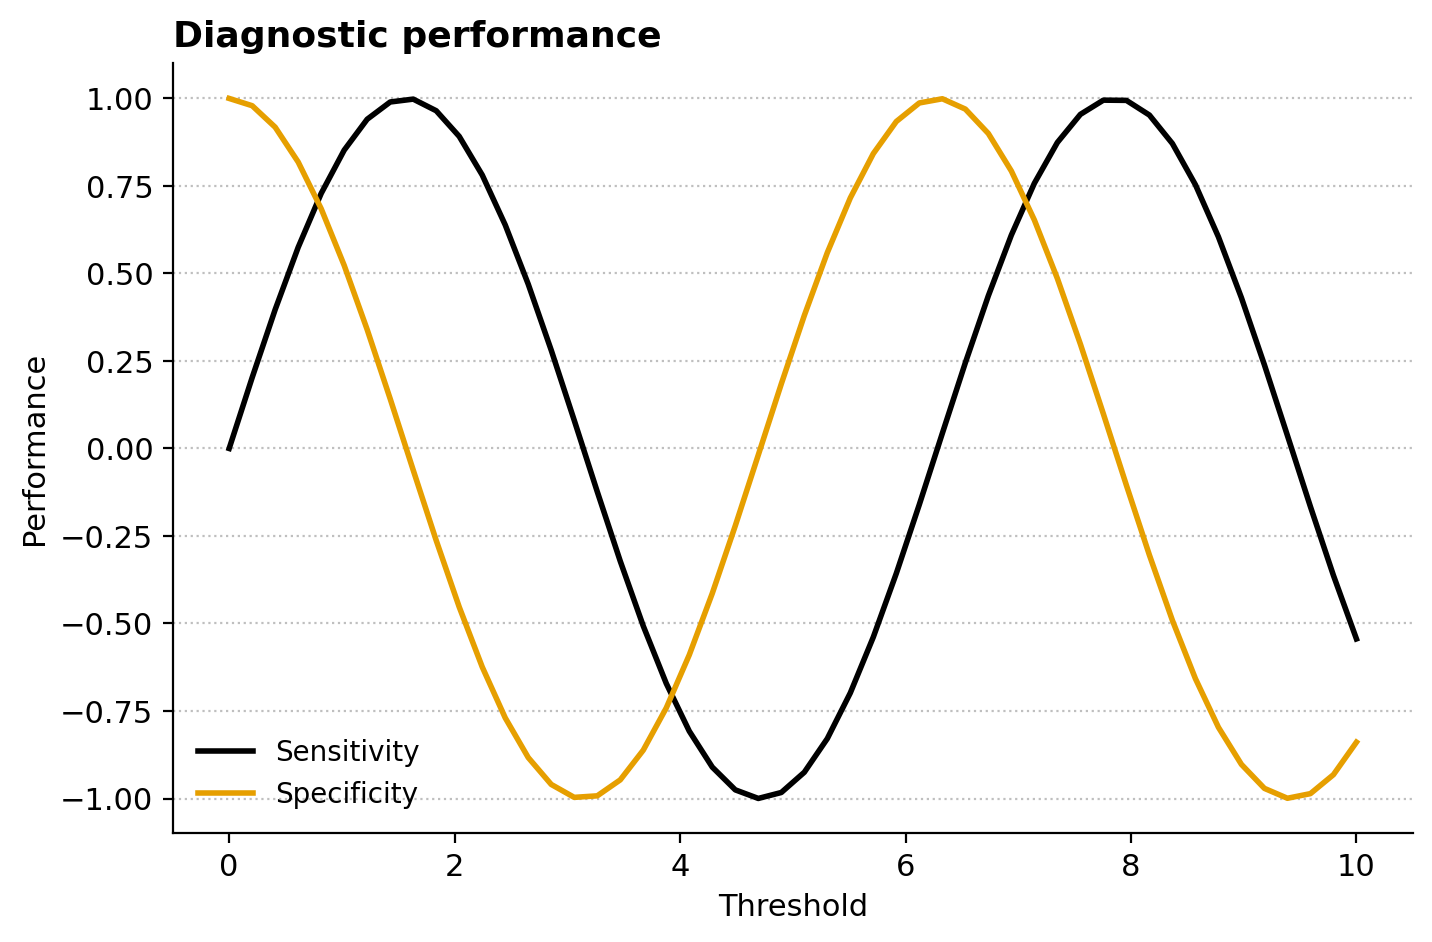

In [13]:
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 50)

def make_plot():
    fig, ax = plt.subplots()
    ax.plot(x, np.sin(x), label="Sensitivity")
    ax.plot(x, np.cos(x), label="Specificity")
    ax.set_title("Diagnostic performance")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Performance")
    ax.legend()
    plt.show()

# Plot 1: factory defaults
with plt.style.context("default"):
    make_plot()

# Plot 2: project style
with plt.style.context("styles/radai.mplstyle"):
    make_plot()

The function body is identical. The visual difference comes from the style. That is the payoff of this module.

## Exercises

### Exercise 1

In a fresh notebook, set these values with `plt.rcParams.update(...)`, then make any simple line plot. Note which changes have visible effects.

```python
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.linestyle": ":",
    "grid.alpha": 0.4,
})
```

### Exercise 2

Cycle through three built-in styles with `plt.style.context(...)`:

- `"ggplot"`
- `"seaborn-v0_8-whitegrid"`
- `"fivethirtyeight"`

Draw the same plot in each. Note which feels closest to radiology publication style.

### Exercise 3

Create `radai.mplstyle` with the contents from section 5, or your own variation. Save it next to the notebook or under a project `styles/` folder. Apply it with:

```python
plt.style.use("styles/radai.mplstyle")
```

Verify that a plot reflects the settings: Okabe-Ito colors, hidden top/right spines, and dotted y-grid.

### Exercise 4

Create a second style file, `radai-slides.mplstyle`, identical to `radai.mplstyle` except:

```text
figure.figsize: 11, 6.5
font.size: 16
axes.titlesize: 20
lines.linewidth: 3
```

Make the same plot with each style applied and compare.

### Exercise 5: synthesis

Take the radiology dashboard from Module 6. Strip out the per-plot styling commands:

- no `ax.spines[...].set_visible(...)`
- no manual color hex codes
- no manual font sizes

Then apply the `radai` style at the top. The dashboard should still look polished, driven by the style file rather than inline styling.

This exercise shows the value of project-level styling most clearly.

## Key takeaways

- `rcParams` is the central dictionary of matplotlib defaults.
- Per-plot keyword arguments are local; `rcParams` are session-wide; style sheets are reusable.
- `plt.style.context(...)` and `plt.rc_context(...)` are safer than global changes inside notebooks.
- A project-local `.mplstyle` file is best for Quarto books and reproducible publication workflows.
- Styling becomes powerful when plot code focuses on data while style files handle visual defaults.